 # (lab8) Adversarial Search Evolutionary Search Algorithms

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_tree(root_node):
    G = nx.DiGraph()
    labels = {}
    pos = {}
    
    # Helper to build the graph
    def build_graph(node, x=0, y=0, layer=1):
        label = f"{node.name}\n(V:{node.value})" if node.is_terminal() else node.name
        labels[node.name] = label
        pos[node.name] = (x, y)
        
        for i, child in enumerate(node.children):
            G.add_edge(node.name, child.name)
            # Spread children out horizontally based on layer depth
            width = 2 / (layer)
            new_x = x - width/2 + i * width
            build_graph(child, x=new_x, y=y-1, layer=layer+1)

    build_graph(root_node)
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, labels=labels, 
            node_size=3000, node_color="lightblue", 
            font_size=10, font_weight="bold", arrows=True)
    plt.title("Minimax Game Tree")
    plt.show()

## MinMax

In [10]:
class Node:
    # We need 'name' here so the computer knows what "L1" is!
    def __init__(self, name, value=None, children=None):
        self.name = name
        self.value = value
        self.children = children or []

    def is_terminal(self):
        return len(self.children) == 0

    def evaluate(self):
        return self.value

    def get_children(self):
        return self.children

In [ ]:
def minmax(node,depth,maximizingPlayer):
    if depth == 0 or node.is_terminal():
        return node.evaluate()
    
    if maximizingPlayer:
        max_eva = float('-inf')
        for child in node.get_children():
            eva = minmax(child,depth-1,False)
            max_eva = max(max_eva,eva)
        return max_eva
    else:
        min_eva = float('inf')
        for child in node.get_children():
            eva = minmax(child,depth-1,True)
            min_eva = min(min_eva,eva)
        return min_eva

```mermaid

graph TD

    root --> A
    root --> B
    A --> L1
    A --> L2
    
    B --> L3
    B --> L4

```

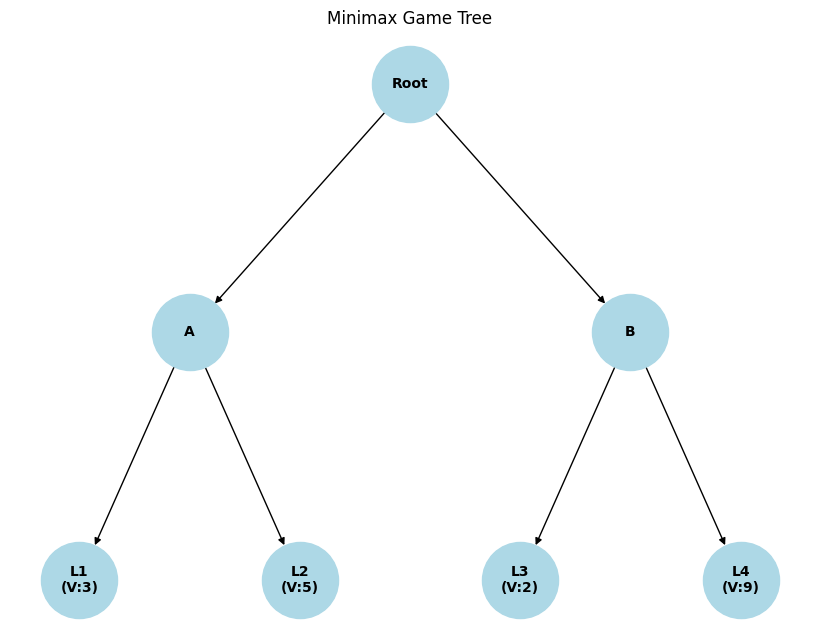

The optimal score for the Maximizer is: 3


In [22]:
# Level 2: Leaf Nodes (The outcomes)
leaf1 = Node("L1", value=3)
leaf2 = Node("L2", value=5)
leaf3 = Node("L3", value=2)
leaf4 = Node("L4", value=9)

# Level 1: Decision Nodes (The opponent's turn)
node_A = Node("A", children=[leaf1, leaf2])
node_B = Node("B", children=[leaf3, leaf4])

# Level 0: Root Node (Your turn)
root = Node("Root", children=[node_A, node_B])

# Run the visualization
draw_tree(root)

result = minmax(root, depth=2, maximizingPlayer=True)
print(f"The optimal score for the Maximizer is: {result}")

In [ ]:
def minimax_ab(node, depth, alpha, beta, maximizingPlayer):
    if depth == 0 or node.is_terminal():
        return node.evaluate()

    if maximizingPlayer:
        max_eva = float('-inf')
        for child in node.get_children():
            eva = minimax_ab(child, depth - 1, alpha, beta, False)
            max_eva = max(max_eva, eva)
            alpha = max(alpha, eva)
            if beta <= alpha:
                break 
        return max_eva

    else:
        min_eva = float('inf')
        for child in node.get_children():
            eva = minimax_ab(child, depth - 1, alpha, beta, True)
            min_eva = min(min_eva, eva)
            beta = min(beta, eva)
            if beta <= alpha:
                break
        return min_eva

In [18]:
result = minimax_ab(root, 2, float('-inf'), float('inf'), True)
print(f"The optimal score for the Maximizer is: {result}")

The optimal score for the Maximizer is: 3
